# Day 2 · 07 — RNN & LSTM: reading text word by word

So far every model looked at **pictures**. A picture arrives all at once. **Text** does not: it is a **sequence**,
and the order matters ("not good" ≠ "good, not").

An **RNN** (recurrent neural network) reads a sentence **one word at a time** and keeps a small **memory**
(the *hidden state*) of what it has read so far. An **LSTM** is an RNN with a better memory.

**Case study:** 📱 is this SMS **spam** or a normal message (**ham**)? This is **text classification**.
It is also the first step of every chatbot: "what does the user want?" (intent classification) is text classification too.

| Step | What we do |
|---|---|
| 1 | download 5,574 real SMS messages (open dataset, UCI) and look at them |
| 2 | turn words into numbers |
| 3 | see what an RNN does with one sentence |
| 4 | train an **LSTM** and measure it properly |
| 5 | compare with a plain **RNN** and with "always say ham" |
| 6 | try your own messages |

⏱️ Runs in about 2 minutes on a CPU. Downloads 200 KB. No GPU, no deployment, just this notebook.

## Step 0 — Setup

Libraries, a fixed random seed (so everybody gets the same numbers), and the download.

In [1]:
import io, re, time, zipfile, urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)
DATA_DIR = Path("..") / "data" / "sms_spam"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FILE = DATA_DIR / "SMSSpamCollection"

if not FILE.exists():
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    with urllib.request.urlopen(url, timeout=60) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extract("SMSSpamCollection", DATA_DIR)

# one message per line:  label <TAB> text
df = pd.read_csv(FILE, sep="\t", header=None, names=["label", "text"], quoting=3)
print(f"{len(df):,} messages")
df.sample(6, random_state=1)

5,574 messages


,label,text
1447,ham,Looks like u wil b getting a headstart im leav...
2032,ham,"I noe la... U wana pei bf oso rite... K lor, o..."
4432,ham,2mro i am not coming to gym machan. Goodnight.
4888,spam,Todays Vodafone numbers ending with 4882 are s...
5276,ham,"Hi. Hope ur day * good! Back from walk, table ..."
5463,ham,Ok i thk i got it. Then u wan me 2 come now or...


## Step 1 — Look at the data first

How many of each kind? This matters for how we judge the model later.

label
ham     4827
spam     747 

ham = 86.6 % of all messages


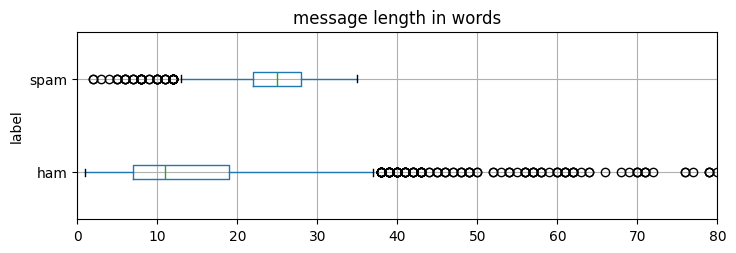

In [2]:
counts = df["label"].value_counts()
print(counts.to_string(), "\n")
print(f"ham = {100 * counts['ham'] / len(df):.1f} % of all messages")

df["words"] = df["text"].str.split().str.len()
df.boxplot(column="words", by="label", vert=False, figsize=(8, 2.5))
plt.suptitle(""); plt.title("message length in words"); plt.xlim(0, 80); plt.show()

👀 **What to notice**

* **87 % of the messages are ham.** A lazy model that always says "ham" is already **87 % accurate**, and it catches **zero** spam.
  So accuracy alone is not enough. We will also look at **spam recall** (how much of the spam we catch) and **spam precision**
  (when we say spam, how often it really is spam). See lesson 9 in `Training_Visualized/`.
* Spam messages are usually **longer**. Most messages have fewer than 40 words, so we will read at most **40 words** per message.

We split once: **80 % for training, 20 % for testing**. The test messages are never used for learning.

In [3]:
df["y"] = (df["label"] == "spam").astype(int)            # 1 = spam, 0 = ham
shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
cut = int(0.8 * len(shuffled))
train_df, test_df = shuffled[:cut], shuffled[cut:]
print(f"train: {len(train_df):,} messages   test: {len(test_df):,} messages")

train: 4,459 messages   test: 1,115 messages


## Step 2 — Words → numbers

A network can only work with numbers. Three small steps:

1. **Split** a message into words (lower-case, keep only letters, digits and a few symbols like `£` and `!`).
2. Build a **vocabulary**: give every word that appears at least twice in the *training* messages its own number.
   Two special numbers: `0` = `<pad>` (empty), `1` = `<unk>` (a word we have never seen).
3. Make every message exactly **40 numbers long**: cut long ones, and fill short ones with `0` **at the front**,
   so the last thing the RNN reads is always the real end of the message.

In [4]:
def words(text):
    return re.findall(r"[a-z0-9£$!]+", text.lower())

counter = Counter(w for t in train_df["text"] for w in words(t))
vocab = {"<pad>": 0, "<unk>": 1}
for w, n in counter.most_common():
    if n >= 2:
        vocab[w] = len(vocab)
print(f"vocabulary: {len(vocab):,} words")

MAX_LEN = 40
def to_numbers(text):
    ids = [vocab.get(w, 1) for w in words(text)][:MAX_LEN]
    return [0] * (MAX_LEN - len(ids)) + ids                  # pad at the front

example = train_df["text"].iloc[3]
print("\ntext   :", example)
print("words  :", words(example)[:12], "...")
print("numbers:", to_numbers(example))

def tensors(frame):
    x = torch.tensor([to_numbers(t) for t in frame["text"]])
    y = torch.tensor(frame["y"].values)
    return x, y

x_train, y_train = tensors(train_df)
x_test, y_test = tensors(test_df)
print("\nx_train:", tuple(x_train.shape), "= (messages, words)")

vocabulary: 3,913 words

text   : Sorry i've not gone to that place. I.ll do so tomorrow. Really sorry.
words  : ['sorry', 'i', 've', 'not', 'gone', 'to', 'that', 'place', 'i', 'll', 'do', 'so'] ...
numbers: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 90, 2, 139, 29, 902, 3, 20, 208, 2, 56, 34, 26, 157, 158, 90]



x_train: (4459, 40) = (messages, words)


## Step 3 — What does an RNN do with one sentence?

Before training, let's watch the machinery on one message. Three layers:

```
word numbers ──► Embedding ──► RNN / LSTM ──► Linear ──► [ham score, spam score]
  (40)          each word →     reads the 32-number     uses only the LAST
                32 numbers      vectors one by one,     memory: "what did the
                                updating a 64-number    whole message say?"
                                memory after each word
```

* **Embedding** = a lookup table: word number → a list of 32 numbers that the network learns (similar words end up with similar lists).
* **RNN step:** `new memory = tanh(W · word + U · old memory)`. The same `W` and `U` are used for every word.

input words      : (1, 40)
after Embedding  : (1, 40, 32)   (1 message, 40 words, 32 numbers per word)
memory after each: (1, 40, 64)   (a 64-number memory after every word)
last memory      : (1, 1, 64)   (this goes to the Linear layer)


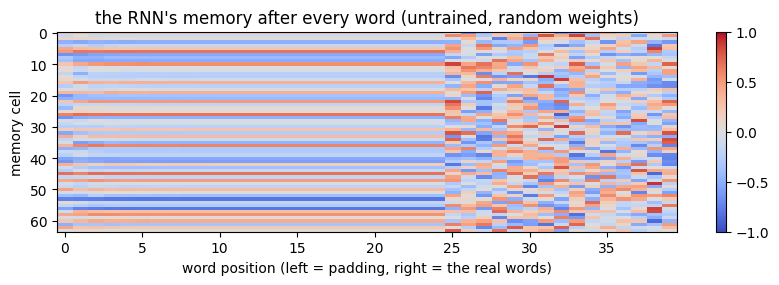

In [5]:
emb = nn.Embedding(len(vocab), 32)
rnn = nn.RNN(input_size=32, hidden_size=64, batch_first=True)

one = x_train[3:4]                                   # 1 message, 40 word numbers
vectors = emb(one)                                   # (1, 40, 32)
all_memories, last_memory = rnn(vectors)
print("input words      :", tuple(one.shape))
print("after Embedding  :", tuple(vectors.shape), "  (1 message, 40 words, 32 numbers per word)")
print("memory after each:", tuple(all_memories.shape), "  (a 64-number memory after every word)")
print("last memory      :", tuple(last_memory.shape), "  (this goes to the Linear layer)")

plt.figure(figsize=(10, 2.6))
plt.imshow(all_memories[0].detach().T, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.xlabel("word position (left = padding, right = the real words)"); plt.ylabel("memory cell")
plt.title("the RNN's memory after every word (untrained, random weights)"); plt.colorbar(); plt.show()

👀 **What to notice:** the left part (padding) looks the same for every message. The memory only starts to change
when the real words arrive. After training, some memory cells will react to spammy words like *free*, *win*, *call*, *£*.

### Why LSTM and not a plain RNN?

A plain RNN multiplies its memory by the same weights at **every** word. Over many words the signal from the early words
fades away (the **vanishing gradient** problem): it forgets the start of long messages.

An **LSTM** adds a second memory line (the **cell state**) and three **gates**, small switches between 0 and 1 that it learns:

| Gate | Question it answers |
|---|---|
| 🚪 forget gate | what should I **forget** from my memory now? |
| 📥 input gate | what from this new word should I **write** into memory? |
| 📤 output gate | what part of my memory should I **show** to the next layer? |

Because the cell state is only changed through these gates (mostly by adding, not multiplying), information can travel over many more words.
In PyTorch the change is one word: `nn.RNN` → `nn.LSTM`. (A **GRU** is a lighter LSTM with two gates.)

## Step 4 — Train an LSTM spam detector

In [6]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, kind="lstm", emb_dim=32, hidden=64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        layer = {"lstm": nn.LSTM, "rnn": nn.RNN, "gru": nn.GRU}[kind]
        self.seq = layer(emb_dim, hidden, batch_first=True)
        self.out = nn.Linear(hidden, 2)

    def forward(self, x):                      # x: (batch, 40) word numbers
        all_memories, _ = self.seq(self.emb(x))
        return self.out(all_memories[:, -1])   # the memory after the LAST word → 2 scores

@torch.inference_mode()
def score(model, x, y):
    model.eval()
    pred = model(x).argmax(1)
    tp = ((pred == 1) & (y == 1)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()
    return {"accuracy_%": round(100 * (pred == y).float().mean().item(), 1),
            "spam_recall_%": round(100 * tp / max(tp + fn, 1), 1),
            "spam_precision_%": round(100 * tp / max(tp + fp, 1), 1)}, pred

def train(kind, epochs=6):
    torch.manual_seed(0)
    model = TextClassifier(len(vocab), kind)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
    history, start = [], time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        scores, _ = score(model, x_test, y_test)
        history.append(scores)
        print(f"{kind.upper():4s} epoch {epoch}: last batch loss {loss.item():.3f} | test " +
              " | ".join(f"{k} {v}" for k, v in scores.items()))
    print(f"⏱️ {time.perf_counter() - start:.0f} s\n")
    return model, history

lstm, lstm_history = train("lstm")

LSTM epoch 1: last batch loss 0.086 | test accuracy_% 95.7 | spam_recall_% 86.5 | spam_precision_% 83.2


LSTM epoch 2: last batch loss 0.020 | test accuracy_% 97.3 | spam_recall_% 86.5 | spam_precision_% 93.7


LSTM epoch 3: last batch loss 0.021 | test accuracy_% 97.8 | spam_recall_% 87.7 | spam_precision_% 95.8


LSTM epoch 4: last batch loss 0.117 | test accuracy_% 97.8 | spam_recall_% 88.4 | spam_precision_% 95.8


LSTM epoch 5: last batch loss 0.002 | test accuracy_% 98.2 | spam_recall_% 90.3 | spam_precision_% 96.6


LSTM epoch 6: last batch loss 0.002 | test accuracy_% 98.2 | spam_recall_% 91.6 | spam_precision_% 95.3
⏱️ 6 s



In [7]:
scores, pred = score(lstm, x_test, y_test)
cm = pd.crosstab(pd.Series(y_test.numpy(), name="true").map({0: "ham", 1: "spam"}),
                 pd.Series(pred.numpy(), name="predicted").map({0: "ham", 1: "spam"}))
print(scores)
cm

{'accuracy_%': 98.2, 'spam_recall_%': 91.6, 'spam_precision_%': 95.3}


predicted,ham,spam
true,,
ham,953,7
spam,13,142


👀 **What to notice**

* Accuracy is high, but look at the **confusion matrix**: the important numbers are the mistakes.
  *true spam → predicted ham* = spam that got through. *true ham → predicted spam* = a real message lost in the spam folder (worse for the user!).
* The LSTM learned all of this from the raw words, with no hand-written rules like "if the message contains FREE".

## Step 5 — Is the LSTM worth it? Compare

Three contenders on the same test messages:

1. 😴 **always "ham"**: the lazy baseline
2. **plain RNN**: same network, `nn.RNN` instead of `nn.LSTM`
3. **LSTM**: from Step 4

RNN  epoch 1: last batch loss 0.383 | test accuracy_% 85.4 | spam_recall_% 41.9 | spam_precision_% 47.1


RNN  epoch 2: last batch loss 0.153 | test accuracy_% 94.3 | spam_recall_% 62.6 | spam_precision_% 95.1


RNN  epoch 3: last batch loss 0.085 | test accuracy_% 95.6 | spam_recall_% 72.9 | spam_precision_% 94.2


RNN  epoch 4: last batch loss 0.057 | test accuracy_% 96.2 | spam_recall_% 85.8 | spam_precision_% 86.9


RNN  epoch 5: last batch loss 0.115 | test accuracy_% 97.3 | spam_recall_% 84.5 | spam_precision_% 95.6


RNN  epoch 6: last batch loss 0.021 | test accuracy_% 97.0 | spam_recall_% 84.5 | spam_precision_% 93.6
⏱️ 6 s



,accuracy_%,spam_recall_%,spam_precision_%
model,,,
always 'ham',86.1,0.0,0.0
plain RNN,97.0,84.5,93.6
LSTM,98.2,91.6,95.3


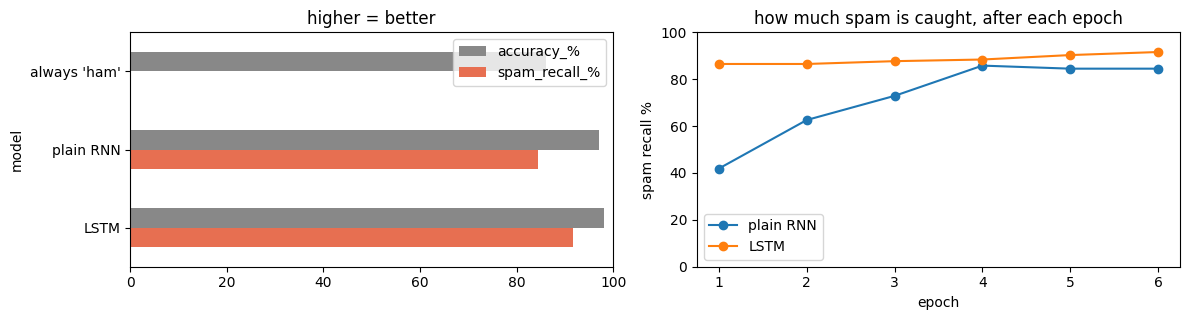

In [8]:
rnn_model, rnn_history = train("rnn")

lazy = {"accuracy_%": round(100 * (y_test == 0).float().mean().item(), 1), "spam_recall_%": 0.0, "spam_precision_%": 0.0}
table = pd.DataFrame([{"model": "always 'ham'", **lazy},
                      {"model": "plain RNN", **score(rnn_model, x_test, y_test)[0]},
                      {"model": "LSTM", **score(lstm, x_test, y_test)[0]}]).set_index("model")
display(table)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.3))
table[["accuracy_%", "spam_recall_%"]].plot.barh(ax=axes[0], color=["#888", "#e76f51"])
axes[0].set_xlim(0, 100); axes[0].set_title("higher = better"); axes[0].invert_yaxis()
for name, h in [("plain RNN", rnn_history), ("LSTM", lstm_history)]:
    axes[1].plot(range(1, len(h) + 1), [s["spam_recall_%"] for s in h], marker="o", label=name)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("spam recall %"); axes[1].set_ylim(0, 100)
axes[1].set_title("how much spam is caught, after each epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

👀 **What to notice**

* The lazy baseline is **86 % accurate** and catches **no spam at all**. That's why we measure spam recall.
* The **plain RNN** starts slowly (after epoch 1 it caught only about 4 in 10 spam messages) and ends lower than the LSTM (about 85 % vs 92 % of spam caught).
  Same data, same size, same training: the only difference is the LSTM's **gates**.
* SMS messages are short, so the gap is modest here. On long texts (reviews, emails) a plain RNN forgets the beginning, and the gap gets much bigger.

## Step 6 — Try your own messages

Change the texts and run the cell again. The model gives a probability of spam between 0 and 1.

In [9]:
@torch.inference_mode()
def spam_probability(text, model=lstm):
    model.eval()
    return torch.softmax(model(torch.tensor([to_numbers(text)])), 1)[0, 1].item()

for text in ["Congratulations! You have won a FREE prize. Call 09061701461 now to claim £1000",
             "Hey, are we still meeting for lunch tomorrow?",
             "URGENT: your mobile number has been selected for a cash reward, text WIN to 80086",
             "Can you send me the notes from today's lecture please",
             "are you free tonight? call me"]:
    p = spam_probability(text)
    print(f"{'🚫 spam' if p > 0.5 else '✅ ham '}  {p:5.2f}  {text}")

🚫 spam   1.00  Congratulations! You have won a FREE prize. Call 09061701461 now to claim £1000
✅ ham    0.00  Hey, are we still meeting for lunch tomorrow?
🚫 spam   1.00  URGENT: your mobile number has been selected for a cash reward, text WIN to 80086
✅ ham    0.00  Can you send me the notes from today's lecture please
✅ ham    0.00  are you free tonight? call me


👀 **Try:** write your own messages. Can you fool the model? It only knows the patterns it saw in 4,459 training messages.

## 🎓 What to remember

1. **Text is a sequence.** An **RNN** reads it one word at a time and carries a **memory** (hidden state) from word to word.
2. Pipeline: **words → numbers (vocabulary) → Embedding → RNN/LSTM → Linear on the last memory**.
3. A plain RNN **forgets** long-ago words (vanishing gradients). An **LSTM** uses **gates** (forget, input, output) to decide what to keep, so it remembers longer. `nn.RNN` → `nn.LSTM` is a one-word change.
4. With **imbalanced** classes (87 % ham), accuracy lies. Check **recall and precision** of the rare class, and compare with a lazy baseline.
5. The same recipe classifies **any** text: reviews (positive/negative), news topics, or a chatbot's **intents** ("book a table", "cancel order").
   Modern chatbots use **Transformers** instead of LSTMs, but the idea "text → numbers → model → class" is the same.

**Want more?** Replace `"lstm"` with `"gru"` in `train(...)`, or set `MAX_LEN = 10` (re-run from Step 2) and see what happens to spam recall.